In [1]:
#!pip install pypalettes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pypalettes import load_cmap, load_palette

In [3]:
df=pd.read_csv("temperature-anomaly.csv")

In [4]:
print(df)

    Entity      Code  Year   Average  Lower bound  Upper bound
0    World  OWID_WRL  1850 -0.062523    -0.235640     0.110594
1    World  OWID_WRL  1851  0.100442    -0.073803     0.274686
2    World  OWID_WRL  1852  0.139907    -0.024693     0.304507
3    World  OWID_WRL  1853  0.101611    -0.057470     0.260692
4    World  OWID_WRL  1854  0.070376    -0.067586     0.208337
..     ...       ...   ...       ...          ...          ...
172  World  OWID_WRL  2022  1.165803     1.128758     1.202849
173  World  OWID_WRL  2023  1.473764     1.436804     1.510725
174  World  OWID_WRL  2024  1.532965     1.493795     1.572135
175  World  OWID_WRL  2025  1.411990     1.372595     1.451385
176  World  OWID_WRL  2026  1.406081     1.322950     1.489211

[177 rows x 6 columns]


In [5]:
years=df["Year"]

In [6]:
tem_ave=df["Average"]

In [7]:
lower_bound=df["Lower bound"]
upper_bound=df["Upper bound"]

In [8]:
colors=load_palette("alice")

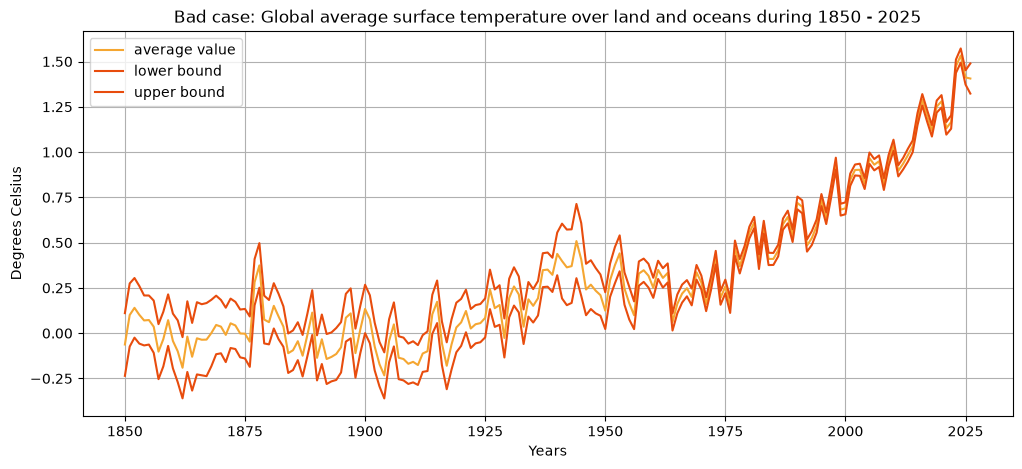

In [37]:
plt.figure(figsize=(12,5))
plt.plot(years,tem_ave,color=colors[0],label="average value")
plt.plot(years,lower_bound,color=colors[1],label="lower bound")
plt.plot(years,upper_bound,color=colors[1],label="upper bound")
plt.title("Bad case: Global average surface temperature over land and oceans during 1850 - 2025")
plt.ylabel("Degrees Celsius")
plt.xlabel("Years")
plt.legend()
plt.grid()

Shortage: 
Figure lines looks mixed up, make it hard to see it clearly.
Gird makes the figure a mess of lines.
upper and lower bound have the same color and have a stronger color than average value, the core data is not emphasized.

Text(0.5, 0, 'Years')

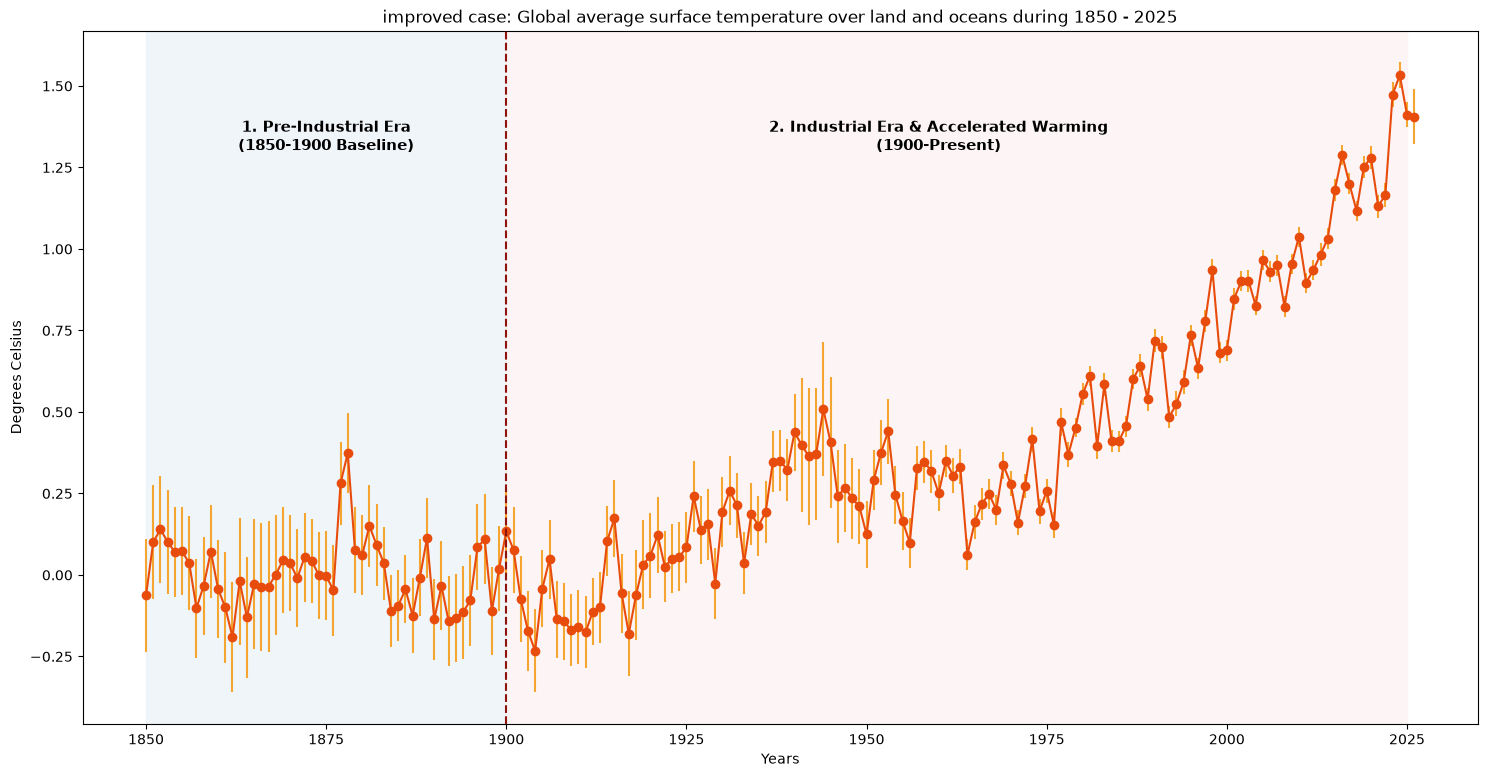

In [44]:

lower=tem_ave-lower_bound
upper=upper_bound-tem_ave
yerr=[lower,upper]
split_year=1900


plt.figure(figsize=(18,9))
plt.errorbar(years,tem_ave,yerr=yerr,fmt="o-",color=colors[1],ecolor=colors[0])
plt.axvline(x=split_year, color=colors[2], linestyle='--', linewidth=1.5, zorder=3)
plt.title("improved case: Global average surface temperature over land and oceans during 1850 - 2025")
plt.axvspan(1850, split_year, color='#eaf2f8', alpha=0.7, zorder=0) 
plt.axvspan(split_year, 2025, color='#fdedec', alpha=0.5, zorder=0)

plt.text(1875, 1.4, 'Pre-Industrial Era\n(1850-1900 Baseline)', 
         fontsize=11, fontweight='bold', ha='center', va='top')
plt.text(1960, 1.4, 'Industrial Era & Accelerated Warming\n(1900-Present)', 
         fontsize=11, fontweight='bold', ha='center', va='top')

plt.yticks(np.arange(-0.25,1.75,0.25))
plt.ylabel("Degrees Celsius")
plt.xlabel("Years")

improvement：
Expand the figsize to make it clear.
Choose error bar to show upper and lower bound instead of two lines.
Set main data(average temperature) a darker color to make it more obvious.
Set a comparation to lead reader pay attention to the temperature change after pre-industrial era.